In [47]:
import numpy as np                
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential


In [48]:
data_train_path = './train'
data_train_test = './test'
data_train_val =  './val'

In [49]:
img_height = 180
img_width = 180

In [50]:
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle= True,
    image_size = (img_width, img_height),
    batch_size = 32,
    validation_split = False)

Found 35168 files belonging to 9 classes.


In [51]:
data_cat = data_train.class_names
class_weight = 'balanced'

In [52]:
data_val = tf.keras.utils.image_dataset_from_directory(
    data_train_val,
    shuffle = False,
    image_size = (img_width, img_height),
    validation_split = False
)

Found 35168 files belonging to 9 classes.


In [53]:
data_test = tf.keras.utils.image_dataset_from_directory(
    data_train_test,
    shuffle = False,
    image_size = (img_width, img_height),
    validation_split = False
)

Found 35168 files belonging to 9 classes.


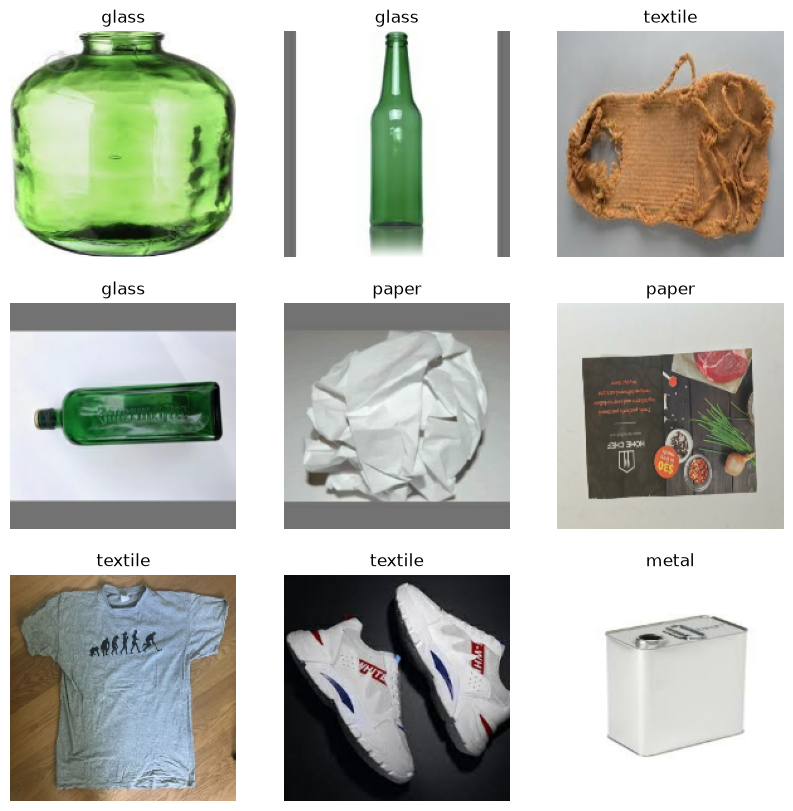

In [54]:
plt.figure(figsize=(10, 10))
for image, lables in data_train.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[lables[i]])
        plt.axis('off')

In [55]:
model = Sequential([
    layers.Rescaling(1. /255),
    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),
    layers.Conv2D(32, 3 , padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_cat))
])

In [56]:
model.compile(optimizer= "adam", loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics= ["accuracy"])

In [ ]:
epoch_size = 30
history = model.fit(data_train, validation_data=data_val, epochs=epoch_size)

Epoch 1/3
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 373s 337ms/step - accuracy: 0.5423 - loss: 1.3401 - val_accuracy: 0.6753 - val_loss: 0.9750
Epoch 2/3
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 362s 330ms/step - accuracy: 0.6712 - loss: 0.9771 - val_accuracy: 0.7636 - val_loss: 0.7341
Epoch 3/3
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 359s 327ms/step - accuracy: 0.7425 - loss: 0.7768 - val_accuracy: 0.8237 - val_loss: 0.5442


In [58]:
image = "./test/metal/garbage_12_metal_metal10.jpg"
image = tf.keras.utils.load_img(image, target_size= (img_height, img_width))
img_arr = tf.keras.utils.img_to_array(image)
img_bat = tf.expand_dims(img_arr, 0)
class_weight = "balanced"

In [59]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


In [60]:
score = tf.nn.softmax(predict)


In [61]:
print("The image is {} and has an Accuracy of {:.2f}%".format(data_cat[np.argmax(score)], np.max(score) * 100))

The image is plastic and has an Accuracy of 45.04%


In [62]:
model.save("Waste_Classification_Model.keras")